# 04 — Models

This notebook trains and evaluates three machine learning classifiers on the land cover labels generated in notebook 03. The three models represent increasing complexity:

1. **K-Means** — unsupervised baseline, no labels needed
2. **Random Forest** — supervised, interpretable, fast to train
3. **U-Net** — supervised deep learning, learns spatial context

Each model is evaluated using overall accuracy, Cohen's Kappa, and per-class F1 score. Results are compared in a single table at the end.

**Inputs:** Feature stacks from Data/Features, training arrays from Data/Labels  
**Outputs:** Trained models, classification maps, accuracy reports saved to Data/Outputs

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip install rasterio scikit-learn --quiet

import numpy as np
import rasterio
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (confusion_matrix, accuracy_score,
                             cohen_kappa_score, classification_report,
                             f1_score)
from sklearn.preprocessing import StandardScaler
import os
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully")

Libraries loaded successfully


In [3]:
# File paths
features_path = '/content/drive/MyDrive/GEOL0069/Project/Data/Features'
labels_path   = '/content/drive/MyDrive/GEOL0069/Project/Data/Labels'
outputs_path  = '/content/drive/MyDrive/GEOL0069/Project/Data/Outputs'

os.makedirs(outputs_path, exist_ok=True)

epochs = ['2019', '2021', '2023', '2025']

# Class definitions — used for all plots and reports
class_names = {
    1: 'Dense woodland',
    2: 'Cropland',
    3: 'Grassland / pasture',
    4: 'Water',
    5: 'Wetland / floodplain',
    6: 'Peri-urban / industrial',
    7: 'Dense urban'
}

class_colours = {
    1: '#1a6b3a',
    2: '#a8c66c',
    3: '#d4e8a0',
    4: '#3b82c4',
    5: '#7ecece',
    6: '#d97706',
    7: '#6b7280'
}

# Colormap for classification maps
cmap_colours = ['#ffffff'] + [class_colours[i] for i in range(1, 8)]
lc_cmap = mcolors.ListedColormap(cmap_colours)
lc_norm = mcolors.BoundaryNorm(range(9), lc_cmap.N)

print("Paths and class definitions set")

Paths and class definitions set


In [4]:
# Load training and test arrays created in notebook 03
X_train = np.load(os.path.join(labels_path, 'X_train.npy'))
X_test  = np.load(os.path.join(labels_path, 'X_test.npy'))
y_train = np.load(os.path.join(labels_path, 'y_train.npy'))
y_test  = np.load(os.path.join(labels_path, 'y_test.npy'))

print(f"Training set: {X_train.shape[0]} pixels, {X_train.shape[1]} features")
print(f"Test set:     {X_test.shape[0]} pixels")
print(f"Classes in training set: {np.unique(y_train)}")

Training set: 30000 pixels, 15 features
Test set:     3010850 pixels
Classes in training set: [1 2 3 4 5 6]


In [5]:
# Load all four feature stacks — we will classify all epochs with each model
print("Loading feature stacks...")
feature_stacks = {}
for epoch in epochs:
    with rasterio.open(os.path.join(features_path, f'features_{epoch}.tif')) as src:
        feature_stacks[epoch] = src.read()
        meta = src.meta.copy()

# Store metadata for saving output maps later
map_meta = meta
map_meta.update({'count': 1, 'dtype': 'int16'})

print(f"Feature stack shape: {feature_stacks['2025'].shape}")
print("All epochs loaded")

Loading feature stacks...
Feature stack shape: (15, 3465, 3212)
All epochs loaded


## Helper functions

Two functions used by all three models:
- `classify_full_image` applies a trained model to an entire feature stack
- `evaluate_model` calculates accuracy metrics and prints a report
- `plot_classification_map` visualises a classified map with the consistent colour scheme

In [6]:
def classify_full_image(model, feature_stack, use_scaler=None):
    """
    Applies a trained sklearn model to a full feature stack.

    Args:
        model: trained sklearn classifier
        feature_stack: array of shape (n_features, height, width)
        use_scaler: optional StandardScaler fitted on training data

    Returns:
        classification map of shape (height, width)
    """
    n_features, h, w = feature_stack.shape

    # Reshape to (n_pixels, n_features)
    X = feature_stack.reshape(n_features, -1).T

    # Replace any non-finite values with 0
    X = np.where(np.isfinite(X), X, 0)

    if use_scaler is not None:
        X = use_scaler.transform(X)

    # Predict in chunks to avoid memory issues
    chunk_size = 500000
    predictions = np.zeros(X.shape[0], dtype='int16')

    for i in range(0, X.shape[0], chunk_size):
        predictions[i:i+chunk_size] = model.predict(X[i:i+chunk_size])

    return predictions.reshape(h, w)


def evaluate_model(name, y_true, y_pred):
    """
    Calculates and prints accuracy metrics for a classification result.
    Returns a dictionary of metrics for the comparison table.
    """
    # Adjust labels to reflect the updated number of classes (1-6)
    oa     = accuracy_score(y_true, y_pred)
    kappa  = cohen_kappa_score(y_true, y_pred)
    f1     = f1_score(y_true, y_pred, average='weighted')
    f1_per = f1_score(y_true, y_pred, average=None, labels=list(range(1, 7))) # Changed range from 1,8 to 1,7

    print(f"\n{'='*50}")
    print(f"Model: {name}")
    print(f"{'='*50}")
    print(f"Overall Accuracy: {oa:.4f} ({oa*100:.1f}%)")
    print(f"Cohen's Kappa:    {kappa:.4f}")
    print(f"Weighted F1:      {f1:.4f}")
    print(f"\nPer-class F1 scores:")
    for i, class_id in enumerate(range(1, 7)): # Changed range from 1,8 to 1,7
        print(f"  {class_names[class_id]:25s}: {f1_per[i]:.3f}")

    return {
        'name': name,
        'oa': oa,
        'kappa': kappa,
        'f1': f1,
        'f1_per_class': f1_per
    }


def plot_classification_map(class_map, title, save_path=None):
    """Plots a classification map using the consistent 7-class colour scheme."""
    fig, ax = plt.subplots(figsize=(10, 11))
    ax.imshow(class_map, cmap=lc_cmap, norm=lc_norm, interpolation='nearest')
    ax.set_title(title, fontsize=13)
    ax.axis('off')

    # Adjust legend patches to reflect the updated number of classes (1-6)
    legend_patches = [
        mpatches.Patch(color=class_colours[i], label=class_names[i])
        for i in range(1, 7) # Changed range from 1,8 to 1,7
    ]
    ax.legend(handles=legend_patches, loc='lower right',
              fontsize=9, framealpha=0.9, title='Land cover class')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

print("Helper function defined")

Helper function defined


## Model 1 — K-Means (unsupervised baseline)

K-Means clusters pixels based on spectral similarity alone, with no knowledge of what the classes are. We use k=7 to match our class scheme, then assign each cluster to a land cover class by comparing the cluster's mean feature values to what we know about each class spectrally.

This is the baseline — we expect it to perform reasonably but to struggle in the peri-urban transition zones where the spectral difference between cropland and bare industrial land is subtle.

In [7]:
print("Training K-Means (k=7)...")

# Scale features — K-Means is sensitive to feature scale
scaler_km = StandardScaler()
X_train_scaled = scaler_km.fit_transform(X_train)
X_test_scaled  = scaler_km.transform(X_test)

# Train K-Means
kmeans = KMeans(n_clusters=7, random_state=42, n_init=10)
kmeans.fit(X_train_scaled)

print("K-Means training complete")
print(f"Cluster centres shape: {kmeans.cluster_centers_.shape}")

Training K-Means (k=7)...
K-Means training complete
Cluster centres shape: (7, 15)


In [8]:
# K-Means assigns arbitrary cluster IDs (0-6) that don't correspond to our class IDs (1-7)
# We need to map each cluster to the correct land cover class
# We do this by looking at which true class label is most common in each cluster

km_train_pred = kmeans.predict(X_train_scaled)

# For each cluster find the most common true label
cluster_to_class = {}
for cluster_id in range(7):
    mask = km_train_pred == cluster_id
    if mask.sum() > 0:
        true_labels = y_train[mask]
        most_common = np.bincount(true_labels.astype(int)).argmax()
        cluster_to_class[cluster_id] = most_common
    else:
        cluster_to_class[cluster_id] = 0

print("Cluster to class mapping:")
for cluster, class_id in cluster_to_class.items():
    class_label = class_names.get(class_id, 'Unknown')
    print(f"  Cluster {cluster} -> Class {class_id}: {class_label}")

Cluster to class mapping:
  Cluster 0 -> Class 4: Water
  Cluster 1 -> Class 2: Cropland
  Cluster 2 -> Class 3: Grassland / pasture
  Cluster 3 -> Class 4: Water
  Cluster 4 -> Class 6: Peri-urban / industrial
  Cluster 5 -> Class 6: Peri-urban / industrial
  Cluster 6 -> Class 1: Dense woodland


In [9]:
# Apply mapping to test predictions
km_test_raw  = kmeans.predict(X_test_scaled)
km_test_pred = np.array([cluster_to_class[c] for c in km_test_raw])

# Remove any pixels mapped to class 0
valid = y_test > 0
km_metrics = evaluate_model('K-Means', y_test[valid], km_test_pred[valid])


Model: K-Means
Overall Accuracy: 0.7190 (71.9%)
Cohen's Kappa:    0.5074
Weighted F1:      0.7217

Per-class F1 scores:
  Dense woodland           : 0.605
  Cropland                 : 0.836
  Grassland / pasture      : 0.548
  Water                    : 0.432
  Wetland / floodplain     : 0.000
  Peri-urban / industrial  : 0.194


Classifying all epochs with K-Means...
  2019: done
  2021: done
  2023: done
  2025: done


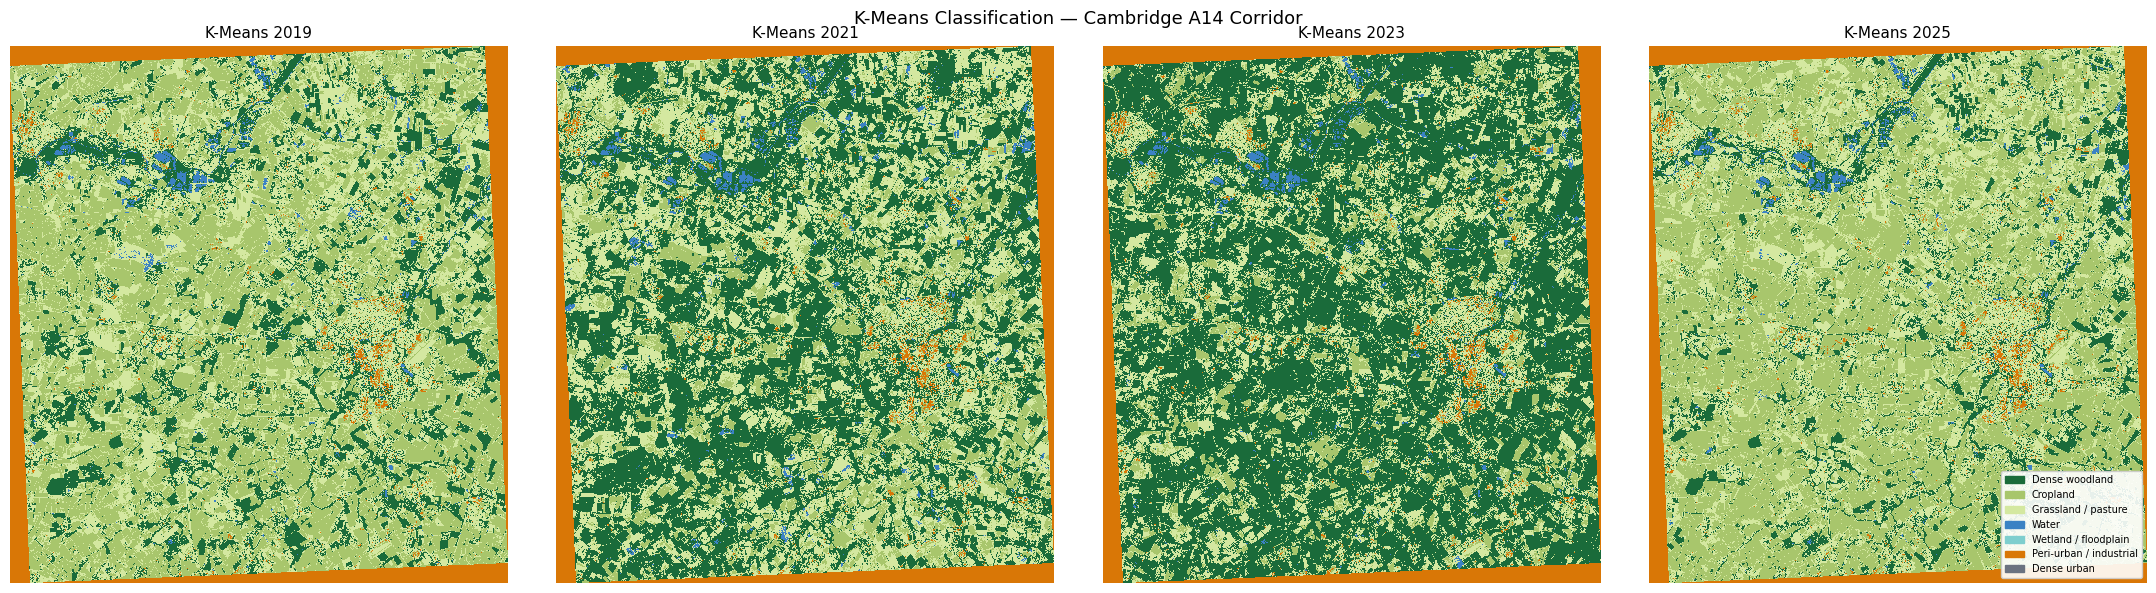

K-Means maps saved


In [10]:
# Apply K-Means to all four epochs and save maps
print("Classifying all epochs with K-Means...")
km_maps = {}

for epoch in epochs:
    raw_map = classify_full_image(kmeans, feature_stacks[epoch], use_scaler=scaler_km)

    # Apply cluster-to-class mapping
    km_map = np.zeros_like(raw_map)
    for cluster, class_id in cluster_to_class.items():
        km_map[raw_map == cluster] = class_id

    km_maps[epoch] = km_map

    # Save as GeoTIFF
    out_path = os.path.join(outputs_path, f'kmeans_{epoch}.tif')
    with rasterio.open(out_path, 'w', **map_meta) as dst:
        dst.write(km_map[np.newaxis, :, :])

    print(f"  {epoch}: done")

# Plot all four epochs
fig, axes = plt.subplots(1, 4, figsize=(22, 6))
for ax, epoch in zip(axes, epochs):
    ax.imshow(km_maps[epoch], cmap=lc_cmap, norm=lc_norm, interpolation='nearest')
    ax.set_title(f'K-Means {epoch}', fontsize=11)
    ax.axis('off')

legend_patches = [mpatches.Patch(color=class_colours[i], label=class_names[i]) for i in range(1,8)]
axes[-1].legend(handles=legend_patches, loc='lower right', fontsize=7, framealpha=0.9)
plt.suptitle('K-Means Classification — Cambridge A14 Corridor', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(outputs_path, 'kmeans_all_epochs.png'), dpi=150, bbox_inches='tight')
plt.show()
print("K-Means maps saved")

Random Forest trains an ensemble of 200 decision trees on the labelled pixels. It is fast, interpretable, and handles the mixed feature types (spectral indices, SAR values, texture) well without needing feature scaling.

After training we extract feature importance — this tells us which of the 15 features contributes most to the classification decisions, which is scientifically interesting and makes a good figure for the project.

In [11]:
print("Training Random Forest (200 trees)...")
print("This takes roughly 2-3 minutes...\n")

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=5,
    class_weight='balanced',  # handles class imbalance
    random_state=42,
    n_jobs=-1  # use all CPU cores
)

rf.fit(X_train, y_train)

print("Random Forest training complete")

Training Random Forest (200 trees)...
This takes roughly 2-3 minutes...

Random Forest training complete


In [12]:
# Evaluate on test set
rf_test_pred = rf.predict(X_test)
rf_metrics = evaluate_model('Random Forest', y_test, rf_test_pred)


Model: Random Forest
Overall Accuracy: 0.7582 (75.8%)
Cohen's Kappa:    0.5965
Weighted F1:      0.7860

Per-class F1 scores:
  Dense woodland           : 0.734
  Cropland                 : 0.865
  Grassland / pasture      : 0.653
  Water                    : 0.403
  Wetland / floodplain     : 0.003
  Peri-urban / industrial  : 0.423


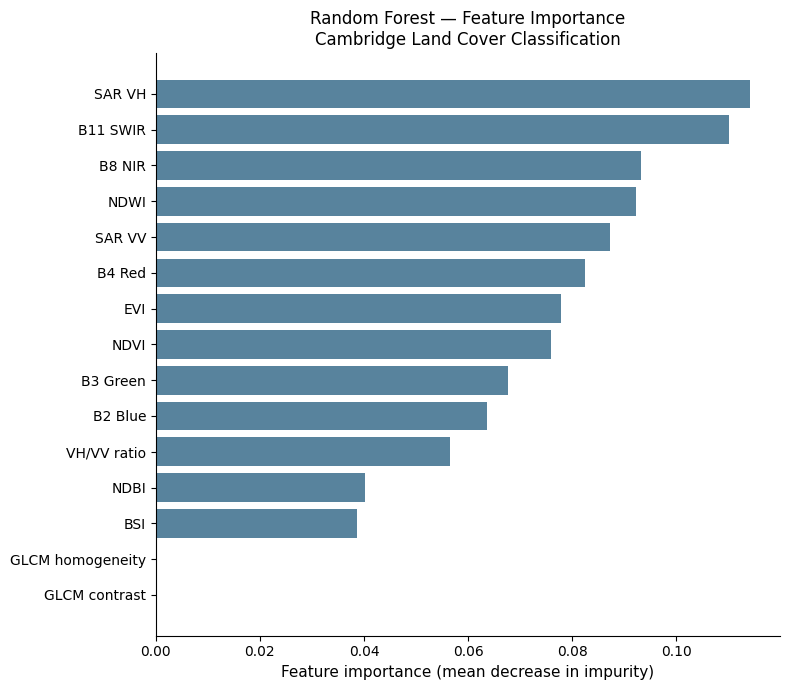

Feature importance plot saved


In [13]:
# Feature importance plot
feature_labels = [
    'NDVI', 'NDWI', 'NDBI', 'BSI', 'EVI',
    'B2 Blue', 'B3 Green', 'B4 Red', 'B8 NIR', 'B11 SWIR',
    'SAR VV', 'SAR VH', 'VH/VV ratio',
    'GLCM contrast', 'GLCM homogeneity'
]

importances = rf.feature_importances_
sorted_idx  = np.argsort(importances)

fig, ax = plt.subplots(figsize=(8, 7))
bars = ax.barh(range(len(importances)),
               importances[sorted_idx],
               color='#3b6d8c', alpha=0.85)
ax.set_yticks(range(len(importances)))
ax.set_yticklabels([feature_labels[i] for i in sorted_idx], fontsize=10)
ax.set_xlabel('Feature importance (mean decrease in impurity)', fontsize=11)
ax.set_title('Random Forest — Feature Importance\nCambridge Land Cover Classification', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(outputs_path, 'rf_feature_importance.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Feature importance plot saved")

Classifying all epochs with Random Forest...
  2019: done
  2021: done
  2023: done
  2025: done


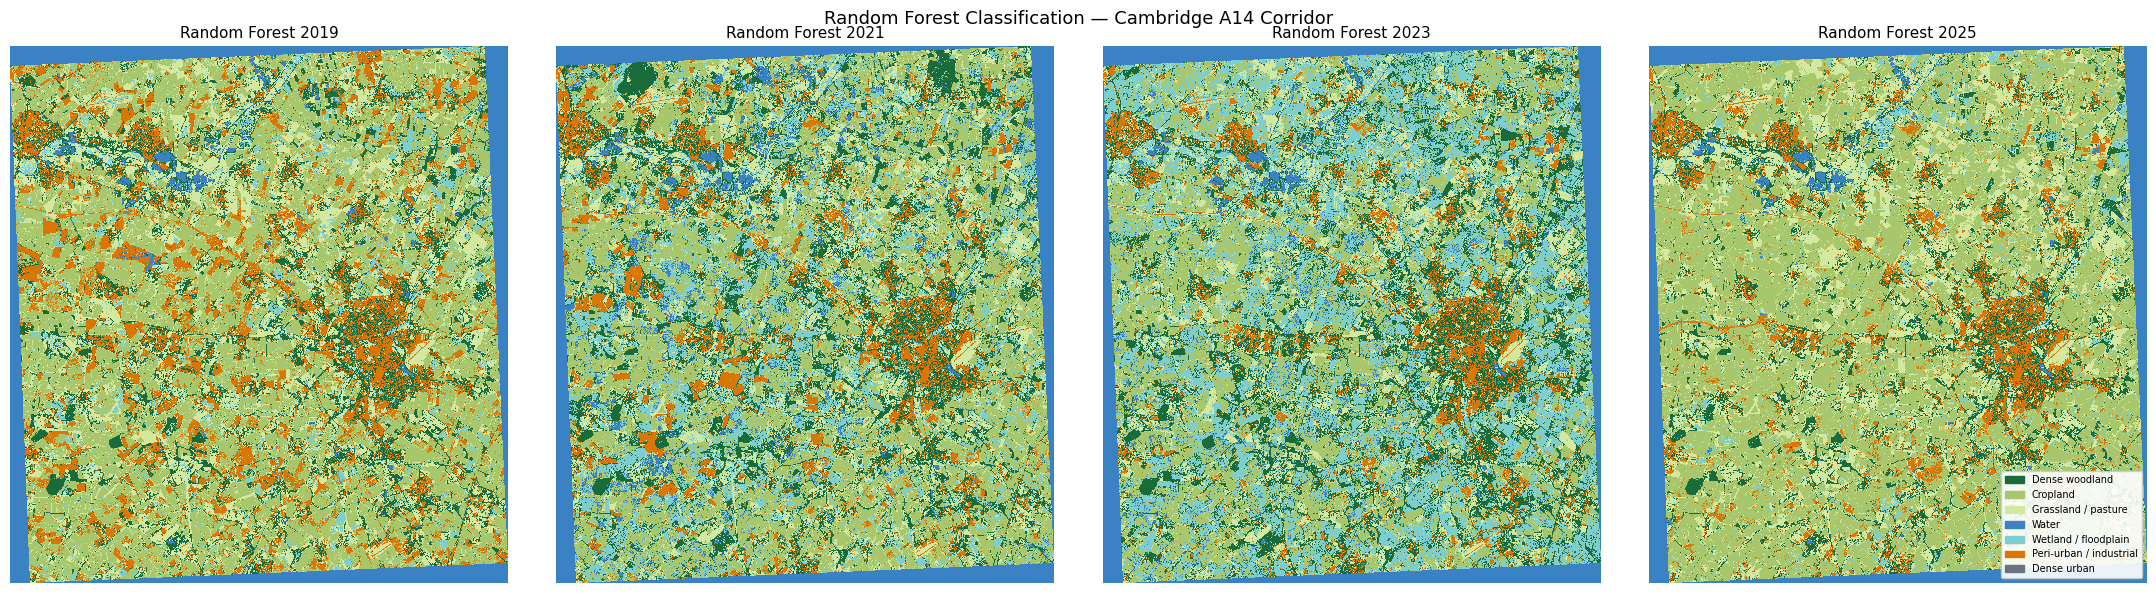

Random Forest maps saved


In [14]:
# Apply Random Forest to all four epochs and save maps
print("Classifying all epochs with Random Forest...")
rf_maps = {}

for epoch in epochs:
    rf_map = classify_full_image(rf, feature_stacks[epoch])
    rf_maps[epoch] = rf_map

    out_path = os.path.join(outputs_path, f'rf_{epoch}.tif')
    with rasterio.open(out_path, 'w', **map_meta) as dst:
        dst.write(rf_map[np.newaxis, :, :])
    print(f"  {epoch}: done")

# Plot all four epochs
fig, axes = plt.subplots(1, 4, figsize=(22, 6))
for ax, epoch in zip(axes, epochs):
    ax.imshow(rf_maps[epoch], cmap=lc_cmap, norm=lc_norm, interpolation='nearest')
    ax.set_title(f'Random Forest {epoch}', fontsize=11)
    ax.axis('off')

legend_patches = [mpatches.Patch(color=class_colours[i], label=class_names[i]) for i in range(1,8)]
axes[-1].legend(handles=legend_patches, loc='lower right', fontsize=7, framealpha=0.9)
plt.suptitle('Random Forest Classification — Cambridge A14 Corridor', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(outputs_path, 'rf_all_epochs.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Random Forest maps saved")

U-Net is a convolutional neural network architecture originally developed for medical image segmentation. Unlike Random Forest which classifies each pixel independently, U-Net looks at a patch of surrounding pixels (spatial context) when making each prediction. This tends to produce smoother, more spatially coherent maps.

We use a lightweight implementation with PyTorch. The model processes 64x64 pixel patches and is trained for 20 epochs. On a Colab T4 GPU this takes roughly 20-30 minutes.

In [15]:
# Check if GPU is available
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("No GPU found — U-Net will train on CPU (slower but will work)")

Using device: cuda
GPU: Tesla T4


In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

class DoubleConv(nn.Module):
    """Two consecutive conv-batchnorm-relu blocks — the basic U-Net building block."""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.net(x)


class UNet(nn.Module):
    """
    Lightweight U-Net for land cover classification.
    Input: (batch, n_features, 64, 64)
    Output: (batch, n_classes, 64, 64)
    """
    def __init__(self, in_channels=15, n_classes=8):
        super().__init__()
        # Encoder
        self.enc1 = DoubleConv(in_channels, 32)
        self.enc2 = DoubleConv(32, 64)
        self.enc3 = DoubleConv(64, 128)
        self.pool = nn.MaxPool2d(2)
        # Bottleneck
        self.bottleneck = DoubleConv(128, 256)
        # Decoder
        self.up3   = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec3  = DoubleConv(256, 128)
        self.up2   = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec2  = DoubleConv(128, 64)
        self.up1   = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.dec1  = DoubleConv(64, 32)
        self.final = nn.Conv2d(32, n_classes, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        b  = self.bottleneck(self.pool(e3))
        d3 = self.dec3(torch.cat([self.up3(b),  e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.final(d1)


print("U-Net architecture defined")

U-Net architecture defined


In [17]:
class PatchDataset(Dataset):
    def __init__(self, feature_stack, label_map, n_patches=8000, patch_size=64):
        self.ps = patch_size
        self.n  = n_patches

        h, w = label_map.shape
        self.max_row = int(h * 0.7) - patch_size
        self.max_col = w - patch_size

        # Clean the feature stack aggressively before storing
        fs = feature_stack.copy().astype('float32')
        fs = np.nan_to_num(fs, nan=0.0, posinf=0.0, neginf=0.0)

        # Normalise each feature band to 0-1 range
        for i in range(fs.shape[0]):
            band = fs[i]
            bmin, bmax = band.min(), band.max()
            if bmax > bmin:
                fs[i] = (band - bmin) / (bmax - bmin)
            else:
                fs[i] = 0.0

        self.features = fs
        self.labels   = label_map.copy()

        np.random.seed(42)
        self.rows = np.random.randint(0, self.max_row, n_patches)
        self.cols = np.random.randint(0, self.max_col, n_patches)

    def __len__(self):
        return self.n

    def __getitem__(self, idx):
        r, c = self.rows[idx], self.cols[idx]
        ps   = self.ps
        patch_x = self.features[:, r:r+ps, c:c+ps]
        patch_y = self.labels[r:r+ps, c:c+ps].astype('int64')
        return torch.tensor(patch_x), torch.tensor(patch_y)


with rasterio.open(os.path.join(labels_path, 'labels_worldcover.tif')) as src:
    label_map_full = src.read(1)

label_map_train = label_map_full.copy()

dataset    = PatchDataset(feature_stacks['2025'], label_map_train, n_patches=8000)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True, num_workers=2)

print(f"Dataset: {len(dataset)} patches of 64x64 pixels")
print(f"Feature value range check: min={dataset.features.min():.3f}, max={dataset.features.max():.3f}")
print(f"Any NaN in features: {np.isnan(dataset.features).any()}")

Dataset: 8000 patches of 64x64 pixels
Feature value range check: min=0.000, max=1.000
Any NaN in features: False


In [18]:
# Merge dense urban (7) into peri-urban (6) since WorldCover
# does not distinguish them — acknowledge this in write-up
label_map_full[label_map_full == 7] = 6

# Update class names to reflect this
class_names = {
    1: 'Dense woodland',
    2: 'Cropland',
    3: 'Grassland / pasture',
    4: 'Water',
    5: 'Wetland / floodplain',
    6: 'Built-up / urban',
}

print("Dense urban merged into built-up/urban class")
print("Class scheme is now 6 classes")

Dense urban merged into built-up/urban class
Class scheme is now 6 classes


In [19]:
model     = UNet(in_channels=15, n_classes=8).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=0)
optimizer = optim.Adam(model.parameters(), lr=1e-4)  # lower learning rate
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.5)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model parameters: {n_params:,}")
print(f"Training for 20 epochs on {device}...\n")

train_losses = []

for epoch in range(20):
    model.train()
    epoch_loss = 0
    valid_batches = 0

    for batch_x, batch_y in dataloader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()
        output = model(batch_x)
        loss   = criterion(output, batch_y)

        # Skip batch if loss is NaN
        if torch.isnan(loss):
            continue

        loss.backward()

        # Clip gradients to prevent explosion
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        epoch_loss += loss.item()
        valid_batches += 1

    scheduler.step()
    avg_loss = epoch_loss / max(valid_batches, 1)
    train_losses.append(avg_loss)

    if (epoch + 1) % 5 == 0:
        print(f"  Epoch {epoch+1:2d}/20 — loss: {avg_loss:.4f}  (valid batches: {valid_batches}/{len(dataloader)})")

print("\nU-Net training complete")

Model parameters: 1,932,104
Training for 20 epochs on cuda...

  Epoch  5/20 — loss: 0.4929  (valid batches: 250/250)
  Epoch 10/20 — loss: 0.3436  (valid batches: 250/250)
  Epoch 15/20 — loss: 0.2872  (valid batches: 250/250)
  Epoch 20/20 — loss: 0.2650  (valid batches: 250/250)

U-Net training complete


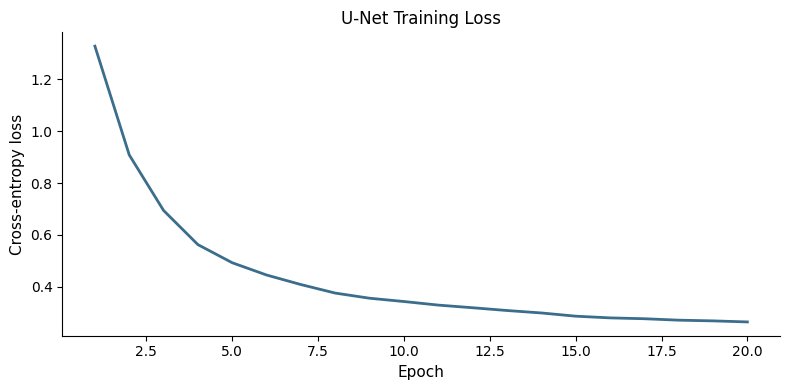

In [20]:
# Plot training loss curve
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, 21), train_losses, color='#3b6d8c', linewidth=2)
ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('Cross-entropy loss', fontsize=11)
ax.set_title('U-Net Training Loss', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(outputs_path, 'unet_training_loss.png'), dpi=150, bbox_inches='tight')
plt.show()

In [21]:
def normalise_stack(feature_stack):
    """
    Applies the same per-band 0-1 normalisation used during U-Net training.
    """
    fs = feature_stack.copy().astype('float32')
    fs = np.nan_to_num(fs, nan=0.0, posinf=0.0, neginf=0.0)
    for i in range(fs.shape[0]):
        band = fs[i]
        bmin, bmax = band.min(), band.max()
        if bmax > bmin:
            fs[i] = (band - bmin) / (bmax - bmin)
        else:
            fs[i] = 0.0
    return fs


def classify_unet(model, feature_stack, patch_size=64, device='cpu'):
    """
    Classifies a full image using the U-Net by running sliding window patches.
    Applies the same normalisation used during training.
    """
    # Normalise before inference
    feature_stack = normalise_stack(feature_stack)

    n_features, h, w = feature_stack.shape
    output_map = np.zeros((h, w), dtype='float32')
    counts     = np.zeros((h, w), dtype='float32')

    model.eval()
    with torch.no_grad():
        for r in range(0, h - patch_size + 1, patch_size // 2):
            for c in range(0, w - patch_size + 1, patch_size // 2):
                patch = feature_stack[:, r:r+patch_size, c:c+patch_size]
                x = torch.tensor(patch[np.newaxis].astype('float32')).to(device)
                pred = model(x).argmax(dim=1).squeeze().cpu().numpy()
                output_map[r:r+patch_size, c:c+patch_size] += pred.astype('float32')
                counts[r:r+patch_size, c:c+patch_size] += 1

    counts = np.maximum(counts, 1)
    return (output_map / counts).astype('int16')

print("Fixed classify_unet function defined")

Fixed classify_unet function defined


Classifying all epochs with U-Net (this takes a while)...
  Processing 2019...
  Processing 2021...
  Processing 2023...
  Processing 2025...


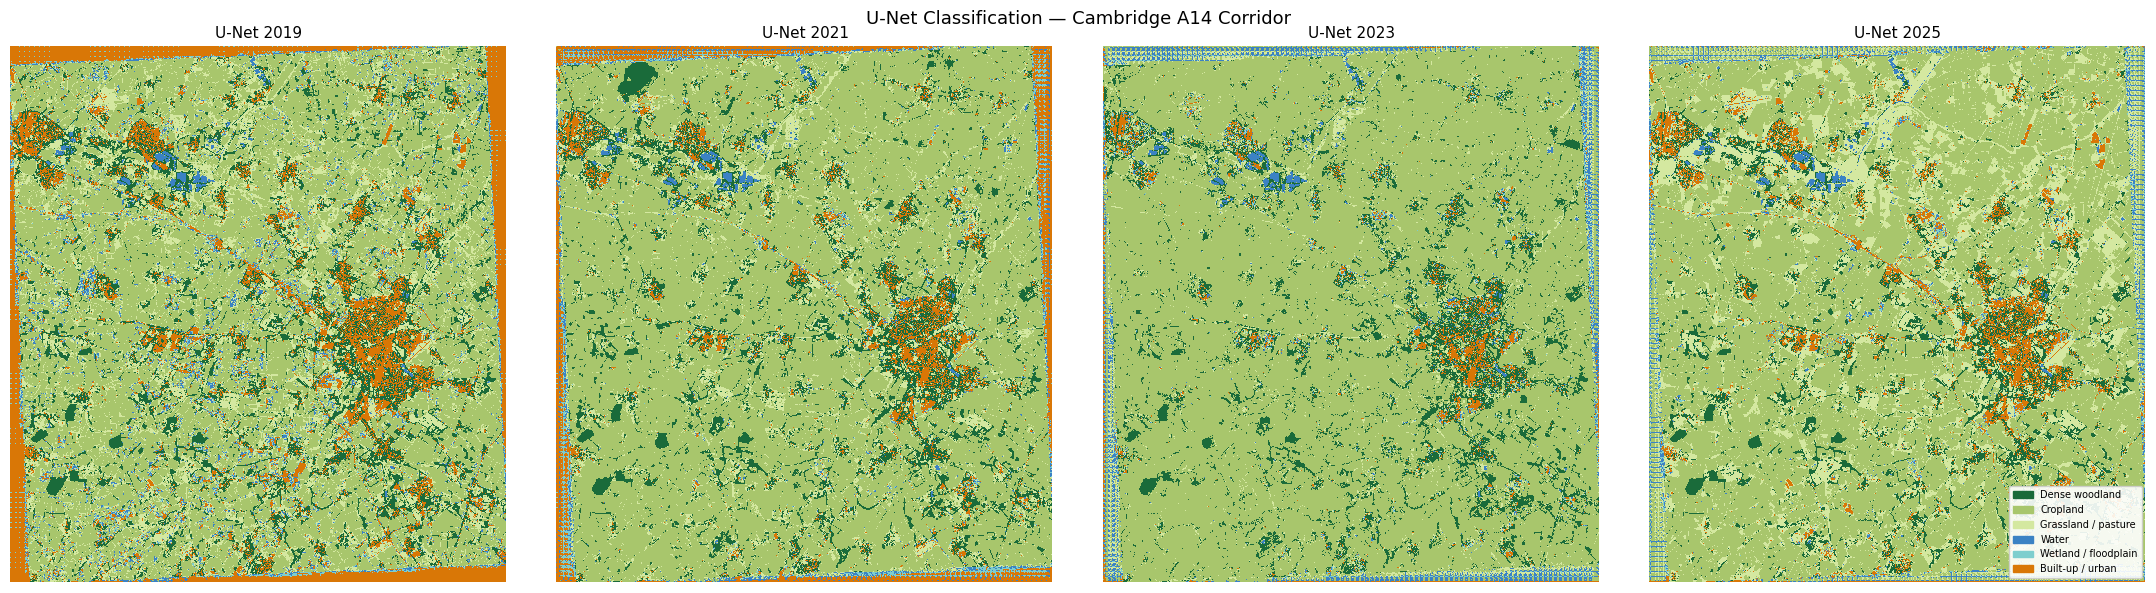

U-Net maps saved


In [22]:
# Apply U-Net to all four epochs
print("Classifying all epochs with U-Net (this takes a while)...")
unet_maps = {}

for epoch in epochs:
    print(f"  Processing {epoch}...")
    unet_map = classify_unet(model, feature_stacks[epoch], device=device)
    unet_maps[epoch] = unet_map

    out_path = os.path.join(outputs_path, f'unet_{epoch}.tif')
    with rasterio.open(out_path, 'w', **map_meta) as dst:
        dst.write(unet_map[np.newaxis, :, :])

# Plot all four epochs
fig, axes = plt.subplots(1, 4, figsize=(22, 6))
for ax, epoch in zip(axes, epochs):
    ax.imshow(unet_maps[epoch], cmap=lc_cmap, norm=lc_norm, interpolation='nearest')
    ax.set_title(f'U-Net {epoch}', fontsize=11)
    ax.axis('off')

legend_patches = [mpatches.Patch(color=class_colours[i], label=class_names[i]) for i in range(1,7)] # Changed range from 1,8 to 1,7
axes[-1].legend(handles=legend_patches, loc='lower right', fontsize=7, framealpha=0.9)
plt.suptitle('U-Net Classification — Cambridge A14 Corridor', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(outputs_path, 'unet_all_epochs.png'), dpi=150, bbox_inches='tight')
plt.show()
print("U-Net maps saved")

Bringing together the accuracy metrics from all three models into a single comparison table. This is the key results table for the project.


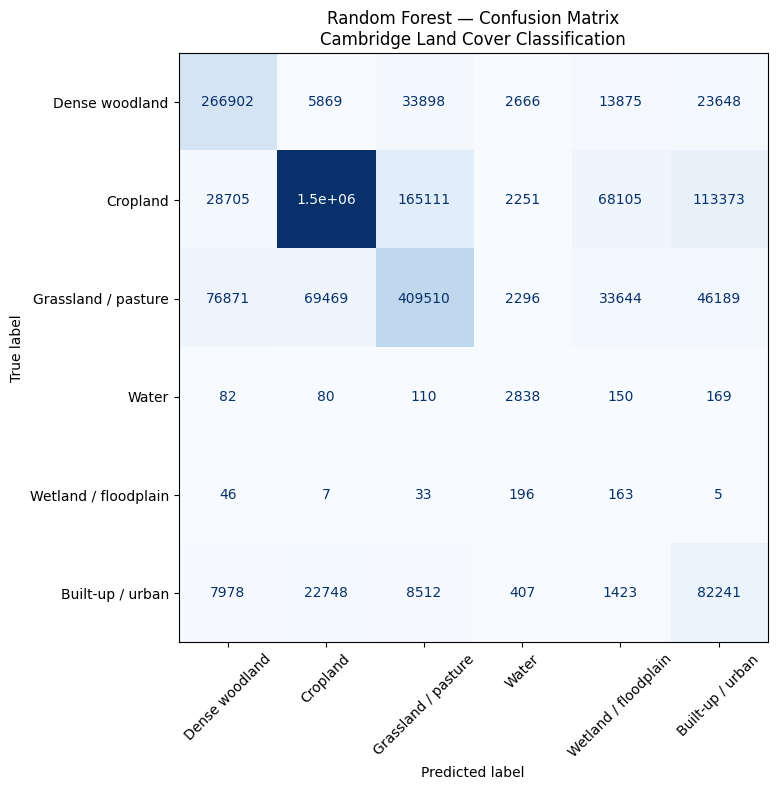

In [23]:
# Confusion matrix for the best model (Random Forest)
from sklearn.metrics import ConfusionMatrixDisplay

rf_pred_all = rf.predict(X_test)
cm = confusion_matrix(y_test, rf_pred_all, labels=list(range(1, 7))) # Changed range from 1,8 to 1,7

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[class_names[i] for i in range(1, 7)] # Changed range from 1,8 to 1,7
)
disp.plot(ax=ax, cmap='Blues', colorbar=False, xticks_rotation=45)
ax.set_title('Random Forest — Confusion Matrix\nCambridge Land Cover Classification', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(outputs_path, 'rf_confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

In [24]:
# Re-evaluate U-Net on test set with corrected normalised inference
split_row = int(feature_stacks['2025'].shape[1] * 0.7)
test_features = feature_stacks['2025'][:, split_row:, :]
unet_test_map = classify_unet(model, test_features, device=device)

test_labels_flat = label_map_full[split_row:].flatten()
unet_pred_flat   = unet_test_map.flatten()

valid = test_labels_flat > 0
unet_metrics = evaluate_model('U-Net', test_labels_flat[valid], unet_pred_flat[valid])


Model: U-Net
Overall Accuracy: 0.7741 (77.4%)
Cohen's Kappa:    0.6069
Weighted F1:      0.7929

Per-class F1 scores:
  Dense woodland           : 0.796
  Cropland                 : 0.864
  Grassland / pasture      : 0.631
  Water                    : 0.054
  Wetland / floodplain     : 0.000
  Built-up / urban         : 0.544


In [25]:
# Summary comparison table
print("\n" + "="*75)
print(f"{'MODEL COMPARISON SUMMARY':^75}")
print("="*75)
print(f"{'Model':<25} {'Overall Acc':>12} {'Kappa':>10} {'Weighted F1':>12}")
print("-"*75)

for metrics in [km_metrics, rf_metrics, unet_metrics]:
    print(f"{metrics['name']:<25} {metrics['oa']*100:>11.1f}% "
          f"{metrics['kappa']:>10.4f} {metrics['f1']:>12.4f}")

print("-"*75)
print("\nPer-class F1 scores:")
print(f"{'Class':<25} {'K-Means':>10} {'Rand Forest':>12} {'U-Net':>8}")
print("-"*60)

for i, class_id in enumerate(range(1, 7)): # Changed range from 1,8 to 1,7
    km_f1 = km_metrics['f1_per_class'][i]
    rf_f1 = rf_metrics['f1_per_class'][i]
    un_f1 = unet_metrics['f1_per_class'][i]
    print(f"{class_names[class_id]:<25} {km_f1:>10.3f} {rf_f1:>12.3f} {un_f1:>8.3f}")

print("\nModels complete. Ready for notebook 05 — change detection.")


                         MODEL COMPARISON SUMMARY                          
Model                      Overall Acc      Kappa  Weighted F1
---------------------------------------------------------------------------
K-Means                          71.9%     0.5074       0.7217
Random Forest                    75.8%     0.5965       0.7860
U-Net                            77.4%     0.6069       0.7929
---------------------------------------------------------------------------

Per-class F1 scores:
Class                        K-Means  Rand Forest    U-Net
------------------------------------------------------------
Dense woodland                 0.605        0.734    0.796
Cropland                       0.836        0.865    0.864
Grassland / pasture            0.548        0.653    0.631
Water                          0.432        0.403    0.054
Wetland / floodplain           0.000        0.003    0.000
Built-up / urban               0.194        0.423    0.544

Models complete. Ready